<a href="https://colab.research.google.com/github/NehalShahu/NNDL_practicals/blob/main/NNDL_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# ============================================================
# REAL-WORLD OBJECT DETECTION USING CNN
# SSD MobileNet V2 + COCO
# BUILD / LOAD MODEL
# ============================================================

# Install required packages
!pip install -q tensorflow tensorflow-hub opencv-python matplotlib pandas scikit-learn

# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import time
from google.colab import files
from collections import Counter

print("=" * 60)
print("CNN OBJECT DETECTION SYSTEM")
print("=" * 60)

print("TensorFlow version:", tf.__version__)

# ------------------------------------------------------------
# COCO CLASS NAMES
# ------------------------------------------------------------

COCO_CLASSES = {
    1: "person",
    2: "bicycle",
    3: "car",
    4: "motorcycle",
    5: "airplane",
    6: "bus",
    7: "train",
    8: "truck",
    9: "boat",
    10: "traffic light",
    11: "fire hydrant",
    13: "stop sign",
    14: "parking meter",
    15: "bench",
    16: "bird",
    17: "cat",
    18: "dog",
    19: "horse",
    20: "sheep",
    21: "cow",
    22: "elephant",
    23: "bear",
    24: "zebra",
    25: "giraffe",
    27: "backpack",
    28: "umbrella",
    31: "handbag",
    32: "tie",
    33: "suitcase",
    34: "frisbee",
    35: "skis",
    36: "snowboard",
    37: "sports ball",
    38: "kite",
    39: "baseball bat",
    40: "baseball glove",
    41: "skateboard",
    42: "surfboard",
    43: "tennis racket",
    44: "bottle",
    46: "wine glass",
    47: "cup",
    48: "fork",
    49: "knife",
    50: "spoon",
    51: "bowl",
    52: "banana",
    53: "apple",
    54: "sandwich",
    55: "orange",
    56: "broccoli",
    57: "carrot",
    58: "hot dog",
    59: "pizza",
    60: "donut",
    61: "cake",
    62: "chair",
    63: "couch",
    64: "potted plant",
    65: "bed",
    67: "dining table",
    70: "toilet",
    72: "tv",
    73: "laptop",
    74: "mouse",
    75: "remote",
    76: "keyboard",
    77: "cell phone",
    78: "microwave",
    79: "oven",
    80: "toaster",
    81: "sink",
    82: "refrigerator"
}

# ------------------------------------------------------------
# LOAD PRE-TRAINED CNN
# ------------------------------------------------------------

MODEL_URL = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"

print("\nLoading SSD MobileNet V2 CNN...")

detector = hub.load(MODEL_URL)

print("Model loaded successfully!")

# ------------------------------------------------------------
# MODEL INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL INFORMATION")
print("=" * 60)

print("Model: SSD MobileNet V2")
print("Architecture: CNN-based Single Shot Detector")
print("Dataset: MS COCO")
print("Number of COCO classes: 80")
print("Input: RGB image")
print("Output: Bounding boxes + classes + confidence scores")

# ------------------------------------------------------------
# DETECTION FUNCTION
# ------------------------------------------------------------

def detect_objects(image, confidence_threshold=0.40):

    # Convert image to TensorFlow tensor
    input_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.uint8
    )

    input_tensor = input_tensor[tf.newaxis, ...]

    # Measure inference time
    start_time = time.time()

    detections = detector(input_tensor)

    inference_time = time.time() - start_time

    # Extract results
    boxes = detections["detection_boxes"][0].numpy()

    classes = (
        detections["detection_classes"][0]
        .numpy()
        .astype(int)
    )

    scores = (
        detections["detection_scores"][0]
        .numpy()
    )

    height, width, _ = image.shape

    results = []

    for box, class_id, score in zip(
        boxes,
        classes,
        scores
    ):

        if score < confidence_threshold:
            continue

        ymin, xmin, ymax, xmax = box

        x1 = int(xmin * width)
        y1 = int(ymin * height)

        x2 = int(xmax * width)
        y2 = int(ymax * height)

        class_name = COCO_CLASSES.get(
            class_id,
            f"Unknown-{class_id}"
        )

        results.append({
            "class_id": class_id,
            "class_name": class_name,
            "confidence": float(score),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2
        })

    return results, inference_time


# ------------------------------------------------------------
# DRAW BOUNDING BOXES
# ------------------------------------------------------------

def draw_detections(image, results):

    output = image.copy()

    for detection in results:

        x1 = detection["x1"]
        y1 = detection["y1"]
        x2 = detection["x2"]
        y2 = detection["y2"]

        class_name = detection["class_name"]
        confidence = detection["confidence"]

        # Green bounding box
        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        # Label
        label = f"{class_name}: {confidence:.2%}"

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2

        (text_width, text_height), baseline = cv2.getTextSize(
            label,
            font,
            font_scale,
            thickness
        )

        label_y = max(
            y1,
            text_height + baseline + 5
        )

        # Label background
        cv2.rectangle(
            output,
            (x1, label_y - text_height - baseline - 5),
            (x1 + text_width + 10, label_y),
            (0, 255, 0),
            -1
        )

        # Label text
        cv2.putText(
            output,
            label,
            (x1 + 5, label_y - 5),
            font,
            font_scale,
            (0, 0, 0),
            thickness
        )

    return output


print("\nDetection functions are ready.")

print("\n" + "=" * 60)
print("BLOCK 1 COMPLETED")
print("=" * 60)


CNN OBJECT DETECTION SYSTEM
TensorFlow version: 2.20.0

Loading SSD MobileNet V2 CNN...
Model loaded successfully!

MODEL INFORMATION
Model: SSD MobileNet V2
Architecture: CNN-based Single Shot Detector
Dataset: MS COCO
Number of COCO classes: 80
Input: RGB image
Output: Bounding boxes + classes + confidence scores

Detection functions are ready.

BLOCK 1 COMPLETED


UPLOAD IMAGE FOR OBJECT DETECTION


Saving images.jpg to images (1).jpg

Uploaded image: images (1).jpg
Image size: (678, 452, 3)


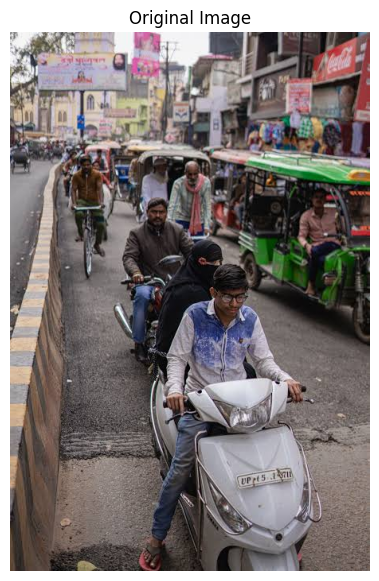


Running CNN object detection...
Detection completed!

DETECTION RESULTS
Total objects detected: 34
Inference time: 0.1282 seconds
Approximate FPS: 7.80

Detected Classes:
  person: 27
  car: 4
  motorcycle: 2
  horse: 1

Detailed Detection Table:


,Object #,Class,Confidence,X1,Y1,X2,Y2
0,1,person,0.7989,162,280,378,665
1,2,car,0.6749,2,138,24,177
2,3,person,0.6579,142,198,223,359
3,4,motorcycle,0.6298,192,408,389,672
4,5,motorcycle,0.6276,166,283,387,674
5,6,person,0.6038,205,160,253,265
6,7,person,0.5698,158,211,251,522
7,8,person,0.5675,139,166,162,222
8,9,person,0.5429,125,163,143,217
9,10,person,0.5304,74,146,128,301


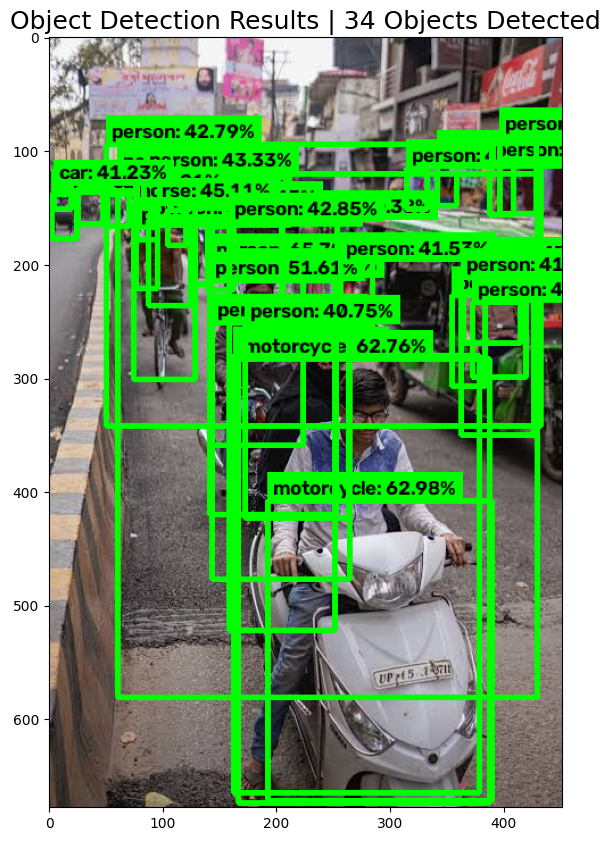

In [29]:
# ============================================================
# UPLOAD IMAGE + OBJECT DETECTION + RESULTS
# ============================================================

print("=" * 60)
print("UPLOAD IMAGE FOR OBJECT DETECTION")
print("=" * 60)

# ------------------------------------------------------------
# UPLOAD IMAGE
# ------------------------------------------------------------

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("\nUploaded image:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Could not read image.")

# Convert BGR -> RGB
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

original_image = image.copy()

print("Image size:", image.shape)

# ------------------------------------------------------------
# DISPLAY ORIGINAL IMAGE
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(original_image)

plt.title("Original Image")

plt.axis("off")

plt.show()

# ------------------------------------------------------------
# RUN DETECTION
# ------------------------------------------------------------

print("\nRunning CNN object detection...")

results, inference_time = detect_objects(
    image,
    confidence_threshold=0.40
)

print("Detection completed!")

# ------------------------------------------------------------
# DRAW BOUNDING BOXES
# ------------------------------------------------------------

result_image = draw_detections(
    image,
    results
)

# ------------------------------------------------------------
# BASIC RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DETECTION RESULTS")
print("=" * 60)

print(
    "Total objects detected:",
    len(results)
)

print(
    "Inference time:",
    f"{inference_time:.4f} seconds"
)

if inference_time > 0:

    print(
        "Approximate FPS:",
        f"{1 / inference_time:.2f}"
    )

# ------------------------------------------------------------
# CLASS COUNTS
# ------------------------------------------------------------

class_counter = Counter(
    detection["class_name"]
    for detection in results
)

print("\nDetected Classes:")

for class_name, count in class_counter.items():

    print(
        f"  {class_name}: {count}"
    )

# ------------------------------------------------------------
# CREATE RESULTS TABLE
# ------------------------------------------------------------

table_data = []

for i, detection in enumerate(
    results,
    start=1
):

    table_data.append({

        "Object #": i,

        "Class": detection["class_name"],

        "Confidence": round(
            detection["confidence"],
            4
        ),

        "X1": detection["x1"],

        "Y1": detection["y1"],

        "X2": detection["x2"],

        "Y2": detection["y2"]
    })

results_df = pd.DataFrame(
    table_data
)

print("\nDetailed Detection Table:")

if len(results_df) > 0:

    display(results_df)

else:

    print(
        "No objects detected above the confidence threshold."
    )

# ------------------------------------------------------------
# DISPLAY FINAL IMAGE
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

plt.imshow(result_image)

plt.title(
    f"Object Detection Results | "
    f"{len(results)} Objects Detected",
    fontsize=18
)

plt.axis("on")

plt.show()


